In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..')
sys.path.append('../gen_data/')
from utils import julio
import importlib
# importlib.reload(julio)
import pandas as pd
import src.observables as obs
importlib.reload(obs)
import utils.io as io
from read_corrs import read_corrs, select_dV
import matplotlib as mpl
mpl.style.use('aps.mplstyle')
import set_size_helper as ssh
# importlib.reload(ssh)

from scipy.fftpack import fft
import matplotlib as mpl
mpl.style.use('aps.mplstyle')

In [2]:
all_files = []
for N in (64, 128, 256, ):
    for dV in np.arange(3.2, 4.0, 0.05):
        filename = julio.corr_filename_builder(N, 1.0, 0.1, 0.8, dV=dV)
        if os.path.exists(filename):
            all_files.append(filename)
df = julio.load_correlations_files(all_files)
df_i = pd.DataFrame()

idmrg_file_list_dict = {100 : '../../data/iDMRG/rev/scanChi100/corrs/results.h5',
                        200 : '../../data/iDMRG/rev/scanChi200/corrs/results.h5', 
                        400 : '../../data/iDMRG/rev/scanChi400/corrs/results.h5', 
                        800 : '../../data/iDMRG/scanChi800/corrs/results.h5',
                        1000: '../../data/iDMRG/scanChi1000/corrs/results.h5',
                        1200: '../../data/iDMRG/scanChi1200/corrs/results.h5',
}
for chi, idmrg_file in idmrg_file_list_dict.items():
    df_i_chi = read_corrs(idmrg_file)
    df_i_chi['chi'] = chi
    df_i = pd.concat([df_i, df_i_chi])
df.keys(), df_i.keys()

(Index(['szmat', 'chargemat', 'spmmat', 'elecupmat', 'elecdnmat', 'sz_expect',
        'ntot_expect', 'xspin2', 'spin2vec', 'params', 'N', 'dV', 'Vpm',
        'szconn', 'chargeconn', 'spmconn', 'electron_conn', 'filename'],
       dtype='object'),
 Index(['basename', 'src_file', 'dV', 'mean_Sz', 'mean_fill', 'xi',
        'model_params', 'diagnostics', 'charge_corr', 'spinz_corr', 'spsm_corr',
        'electron_corr', 'spin2_corr', 'chi'],
       dtype='object'))

correlation length =  213.08966442133786


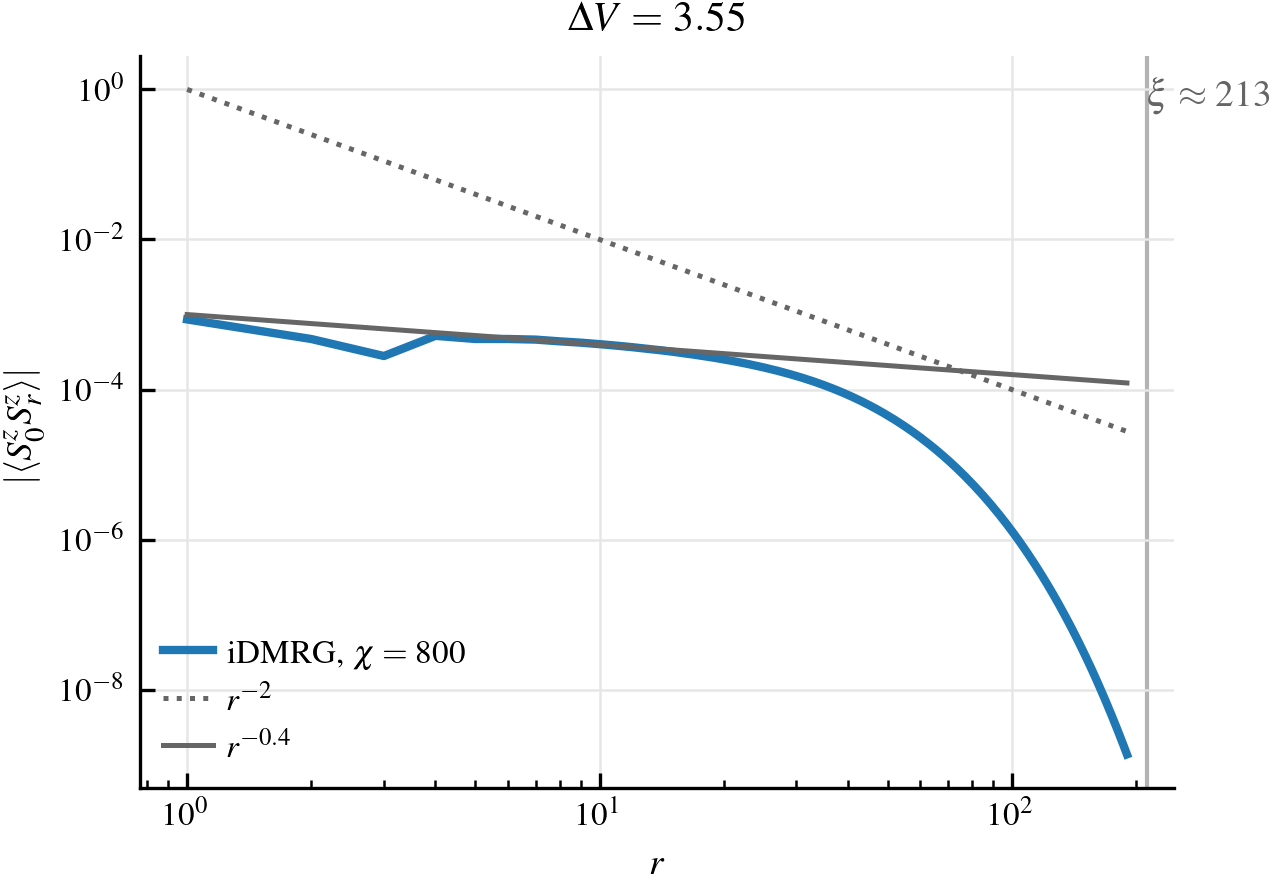

In [3]:
seldf = select_dV(df_i[df_i['chi']==800], 3.55, atol=1e-7)
spinzcorr = np.abs(seldf['spinz_corr'].values[0])
xi = seldf['xi'].values[0]
print('correlation length = ', xi)

r = np.arange(1, len(spinzcorr))  # skip r=0: undefined on log axes
fig, ax = plt.subplots(figsize=(4.5, 3.2))
ax.loglog(r, spinzcorr[1:], color='C0', lw=2, label=r'iDMRG, $\chi=800$')
ax.loglog(r, 1./r**2, color='0.4', lw=1.2, ls=':', label=r'$r^{-2}$')
ax.loglog(r, 0.001/r**0.4, color='0.4', lw=1.2, ls='-', label=r'$r^{-0.4}$')
ax.axvline(xi, color='0.7', lw=1, zorder=0)
ax.text(xi, 0.97, rf' $\xi \approx {xi:.0f}$', transform=ax.get_xaxis_transform(),
        va='top', fontsize=9, color='0.4')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$|\langle S^z_0 S^z_r \rangle|$')
ax.set_title(rf'$\Delta V = 3.55$', fontsize=10)
ax.grid(which='major', color='0.9', lw=0.6)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()

No iDMRG data for chi = 400 at dV = 3.55
No iDMRG data for chi = 1200 at dV = 3.55


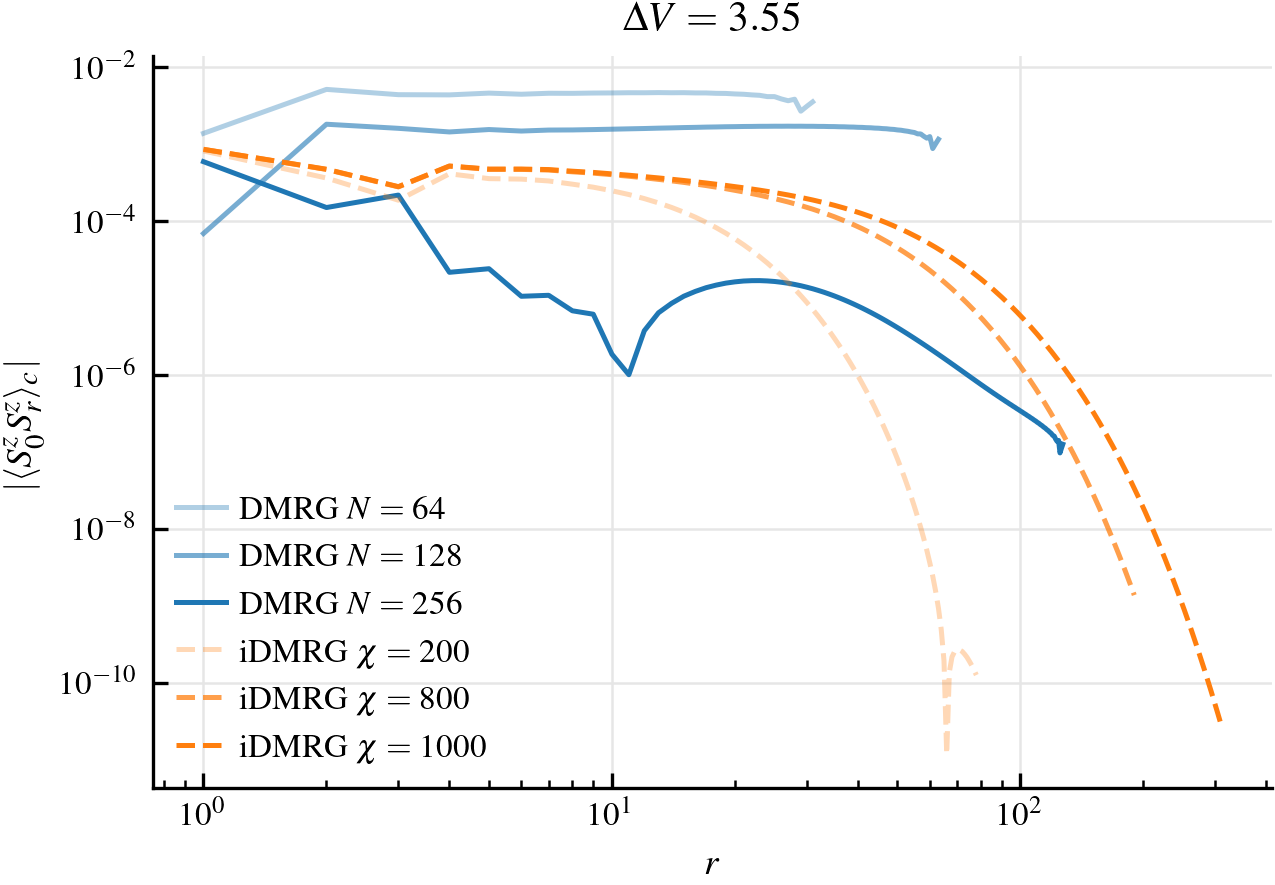

In [4]:
dVval = 3.55
fig, ax = plt.subplots(figsize=(4.5, 3.2))
for nval, alpha in zip((64, 128, 256), (0.35, 0.6, 1.0)):
    seldf = julio.select_N_dv_from_df(nval, dVval, df)
    if seldf.empty:
        continue
    yqty = np.abs(seldf['szconn'].values[0])
    ax.loglog(np.arange(1, len(yqty)), yqty[1:], color='C0', lw=1.2, alpha=alpha, label=rf'DMRG $N={nval}$')

for chival, alpha in zip((200, 400, 800, 1000, 1200), (0.3, 0.5, 0.75, 1.0, 1.0)):
    seldf_i = select_dV(df_i[df_i['chi']==chival], dVval, atol=1e-7)
    if seldf_i.empty:
        print(f'No iDMRG data for chi = {chival} at dV = {dVval}')
        continue
    yqty_i = np.abs(seldf_i['spinz_corr'].values[0])
    ax.loglog(np.arange(1, len(yqty_i)), yqty_i[1:], color='C1', lw=1.2, ls='--', alpha=alpha, label=rf'iDMRG $\chi={chival}$')

rr = np.arange(1, 200)
# ax.loglog(rr, 1./rr**2, color='0.4', lw=1, ls=':', label=r'$r^{-2}$')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$|\langle S^z_0 S^z_r \rangle_c|$')
ax.set_title(rf'$\Delta V = {dVval}$', fontsize=10)
ax.grid(which='major', color='0.9', lw=0.6)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()


In [ ]:
df_cc = read_corrs('../../data/iDMRG/Vpm4.350cc/corrs/results.h5')
df_cc['chi'] = df_cc['basename'].str.extract(r'chi(\d+)', expand=False).astype(int)
df_cc = df_cc.sort_values('chi')

norm = plt.Normalize(df_cc['chi'].min(), df_cc['chi'].max())
cmap = plt.cm.viridis

fig, ax = plt.subplots(1)
fig.set_size_inches(ssh.set_size(subplots=(1,1), fraction=0.75))
for chival, corr in zip(df_cc['chi'], df_cc['spinz_corr']):
    corr = np.abs(corr)
    ax.loglog(np.arange(1, len(corr)), corr[1:], color=cmap(norm(chival)), lw=0.8)

fit_lo, fit_hi = 5, 34  # r window for the power-law fit at the largest chi
corr = np.abs(df_cc['spinz_corr'].iloc[-1])
rfit = np.arange(fit_lo, fit_hi)
slope, logc = np.polyfit(np.log(rfit), np.log(corr[fit_lo:fit_hi]), 1)
rr = np.arange(1, 3*fit_hi)
ax.plot(rr, np.exp(logc)*rr**slope, color='k', lw=0.8, ls='--', zorder=5)
ax.text(0.97, 0.95, rf'$\sim |x|^{{{slope:.2f}}}$', fontsize=8,
        transform=ax.transAxes, va='top', ha='right')
# ax.text(0.04, 0.08, r'$\Delta V = 3.55$', fontsize=8,
#         transform=ax.transAxes, va='bottom', ha='left')

cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.02)
cbar.set_label(r'$\chi$')
cbar.outline.set_linewidth(0.8)
ax.set_ylim(1e-10, 3e-3)
ax.set_xlabel(r'$x$', labelpad=-1)
ax.set_ylabel(r'$|\langle S^z(x) S^z(0) \rangle|$')
ax.set_title(r'iDMRG, $\Delta V = 3.55$')
fig.savefig('figures/SzCorrChiScaling.pdf', bbox_inches='tight')
